# 랜덤포레스트 사용  - 밸런싱o, 밸런싱x 에따른 roc_curve

X_train 크기: (18519, 20)
y_train 크기: (18519,)
X_test 크기 (7938, 20)
y_test 크기 (7938,)


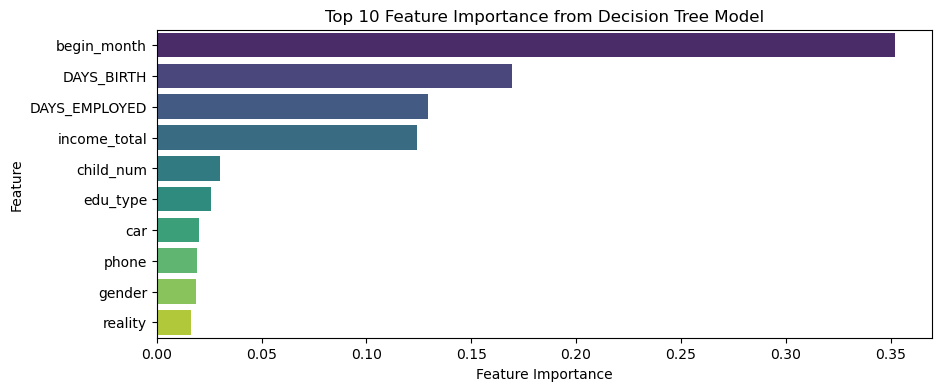

                             feature       VIF
13                         adult_num  3.267071
20  guardian_status_Without Guardian  3.266953
16                occyp_group_Others  3.110440
8                      DAYS_EMPLOYED  2.553054
19             occyp_group_Technical  2.546262
7                         DAYS_BIRTH  1.883709
17                 occyp_group_Sales  1.582125
15            occyp_group_Management  1.554633
1                             gender  1.437189
18               occyp_group_Service  1.434591
9                         work_phone  1.240107
14            occyp_group_Healthcare  1.227171
2                                car  1.221703
5                       income_total  1.216071
6                           edu_type  1.198443
4                          child_num  1.165736
10                             phone  1.125940
3                            reality  1.064593
11                             email  1.033899
12                       begin_month  1.011994


In [2]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:
from sklearn.ensemble import RandomForestClassifier



import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv("data2/train.csv")


# In[2]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv("data2/train.csv")

# 이진 변수는 map으로 처리
df['gender'] = df['gender'].map({'F': 0, 'M': 1})
df['car'] = df['car'].map({'N': 0, 'Y': 1})
df['reality'] = df['reality'].map({'N': 0, 'Y': 1})

# 직업 변수 그룹화 및 결측값 처리
df['occyp_type'].fillna('Others', inplace=True)
job_groups = {
    'Laborers': 'Technical',
    'Managers': 'Management',
    'Sales staff': 'Sales',
    'High skill tech staff': 'Technical',
    'Core staff': 'Administrative',
    'Drivers': 'Technical',
    'Medicine staff': 'Healthcare',
    'Accountants': 'Administrative',
    'Realty agents': 'Sales',
    'Security staff': 'Service',
    'Cleaning staff': 'Service',
    'Private service staff': 'Service',
    'Cooking staff': 'Service',
    'Secretaries': 'Administrative',
    'HR staff': 'Administrative',
    'IT staff': 'Technical',
    'Low-skill Laborers': 'Technical',
    'Waiters/barmen staff': 'Service',
    'Others': 'Others'}
df['occyp_group'] = df['occyp_type'].map(job_groups)


# edu_type 순서형 인코딩
education_order = {
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5}
df['edu_type'] = df['edu_type'].map(education_order)

# guardian_status 변수 생성
guardian_status = {
    'Married': 'With Guardian',
    'Civil marriage': 'With Guardian',
    'Separated': 'With Guardian',
    'Single / not married': 'Without Guardian',
    'Widow': 'Without Guardian'}
df['guardian_status'] = df['family_type'].map(guardian_status)

# 상수형 변수 제거
df.drop(columns=['FLAG_MOBIL'], inplace=True)

# income_type과 house_type 제거
df.drop(columns=['income_type', 'house_type'], inplace=True)

# 성인 수(adult_num) 변수 생성
df['adult_num'] = df['family_size'] - df['child_num']

# 기존 family_size와 child_num 변수 제거
df.drop(columns=['family_size'], inplace=True)

# 필요 시 범주형 변수에 대해 원-핫 인코딩 적용 (기준 변수는 제외)
categorical_columns = ['occyp_group', 'guardian_status']
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# 피처와 타겟 변수 분리
X = df_encoded.drop(columns=['credit', 'index', 'occyp_type', 'family_type'])
y = df_encoded['credit']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("X_train 크기:", X_train.shape)
print("y_train 크기:", y_train.shape)
print("X_test 크기", X_test.shape)
print("y_test 크기", y_test.shape)

# 의사결정 나무 모델 학습
model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)

# 변수 중요도 추출
feature_importances = model.feature_importances_

# 변수 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화 상위 10
plt.figure(figsize=(10, 4))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance from Decision Tree Model')
plt.show()

# 변수 중요도 시각화 전체
#plt.figure(figsize=(10, 4))
#sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
#plt.xlabel('Feature Importance')
#plt.ylabel('Feature')
#plt.title('Feature Importance from Decision Tree Model')
#plt.show()


# In[3]:


from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 다중공선성 확인 (VIF 계산)
X_vif = add_constant(X)
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 상수 열 제거
vif_data = vif_data[vif_data['feature'] != 'const']
print(vif_data.sort_values(by="VIF", ascending=False))



# 밸런싱 안 한 버전 

X_train 크기: (18519, 20)
y_train 크기: (18519,)
X_test 크기 (7938, 20)
y_test 크기 (7938,)
정확도: 0.6963970773494583
              precision    recall  f1-score   support

         0.0       0.42      0.23      0.29       951
         1.0       0.59      0.47      0.52      1872
         2.0       0.75      0.87      0.80      5115

    accuracy                           0.70      7938
   macro avg       0.59      0.52      0.54      7938
weighted avg       0.67      0.70      0.68      7938



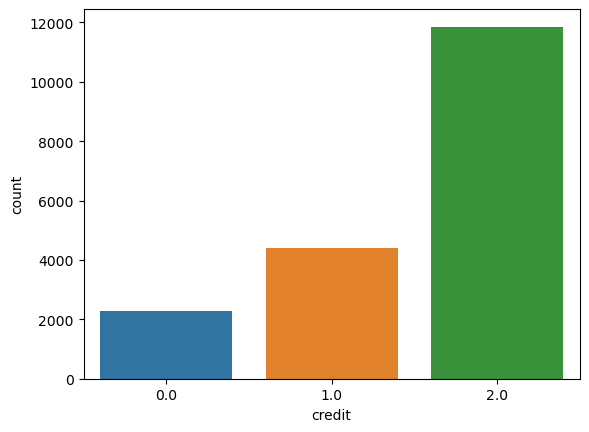

In [3]:

import numpy as np
from sklearn.ensemble import RandomForestClassifier


X = df_encoded.drop(columns=['credit', 'index', 'occyp_type', 'family_type'])
y = df_encoded['credit']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("X_train 크기:", X_train.shape)
print("y_train 크기:", y_train.shape)
print("X_test 크기", X_test.shape)
print("y_test 크기", y_test.shape)

# 의사결정 나무 모델 학습
model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
#print("실제값:", y_test)
#print("예측값:",X_test)

import matplotlib.pyplot as plot
import seaborn as sns

sns.countplot(x=y_train)

from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
y_acc = accuracy_score(y_test, y_pred)
print("정확도:",y_acc)

from sklearn.metrics import classification_report
# 분류 보고서 출력
print(classification_report(y_test, y_pred))

# 밸런싱 안 한 roc cureve 

Class 1 AUC: 0.70
Class 2 AUC: 0.76
Class 3 AUC: 0.75


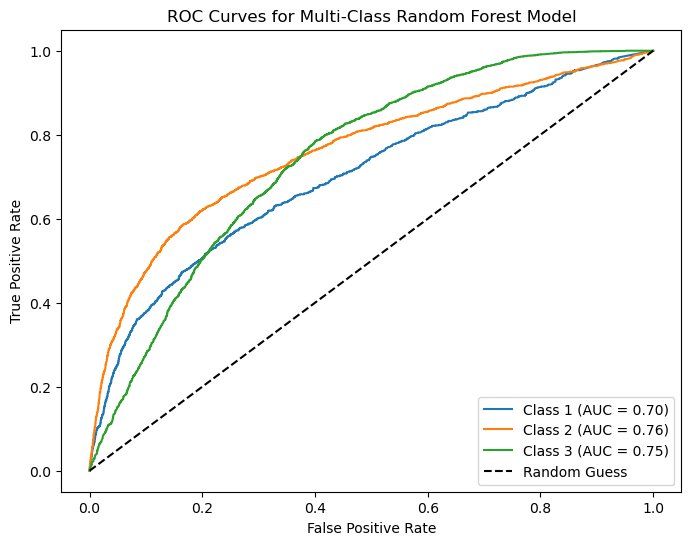

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
import numpy as np

# 다중 클래스 y_test를 이진화 (One-vs-Rest 방식)
y_test_binarized = label_binarize(y_test, classes=np.unique(y_train))
n_classes = y_test_binarized.shape[1]

# One-vs-Rest 방식으로 다중 클래스 분류 모델 학습
model = OneVsRestClassifier(RandomForestClassifier(random_state=0))
model.fit(X_train, y_train)
y_score = model.predict_proba(X_test)

# 각 클래스에 대해 ROC curve와 AUC 계산
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
    print(f"Class {i+1} AUC: {roc_auc[i]:.2f}")

# ROC curve 그리기
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i+1} (AUC = {roc_auc[i]:0.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class Random Forest Model')
plt.legend(loc='lower right')
plt.show()


# 밸런싱 한 버전

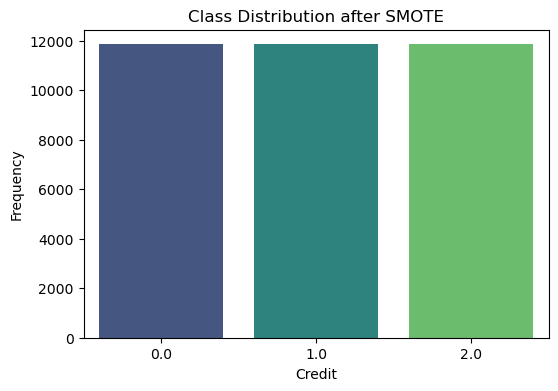

정확도: 0.6783824640967498
              precision    recall  f1-score   support

         0.0       0.37      0.29      0.32       951
         1.0       0.55      0.52      0.53      1872
         2.0       0.77      0.81      0.79      5115

    accuracy                           0.68      7938
   macro avg       0.56      0.54      0.55      7938
weighted avg       0.67      0.68      0.67      7938



In [30]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 피처와 타겟 변수 분리
X = df_encoded.drop(columns=['credit', 'index', 'occyp_type', 'family_type'])
y = df_encoded['credit']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# SMOTE 적용
smote = SMOTE(random_state=0)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 클래스 분포 시각화
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_balanced, palette='viridis')
plt.title('Class Distribution after SMOTE')
plt.xlabel('Credit')
plt.ylabel('Frequency')
plt.show()

# 모델 학습
model = RandomForestClassifier(random_state=0)
model.fit(X_train_balanced, y_train_balanced)

# 예측 및 평가
#y_pred = model.predict(X_test)
#print(classification_report(y_test, y_pred))

from sklearn.metrics import accuracy_score, classification_report

# 테스트 데이터로 예측
y_pred = model.predict(X_test)

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("정확도:", accuracy)

# 분류 보고서 출력
print(classification_report(y_test, y_pred))




# 밸런싱 한 버전 roc curve

C:\Users\chco.DESKTOP-DVEQHPF\anaconda3\lib\site-packages\sklearn\multiclass.py:492: RuntimeWarning: invalid value encountered in divide
  Y /= np.sum(Y, axis=1)[:, np.newaxis]


y_score contains NaN values.
Class 1 AUC: 0.62
Class 2 AUC: 0.66
Class 3 AUC: 0.66


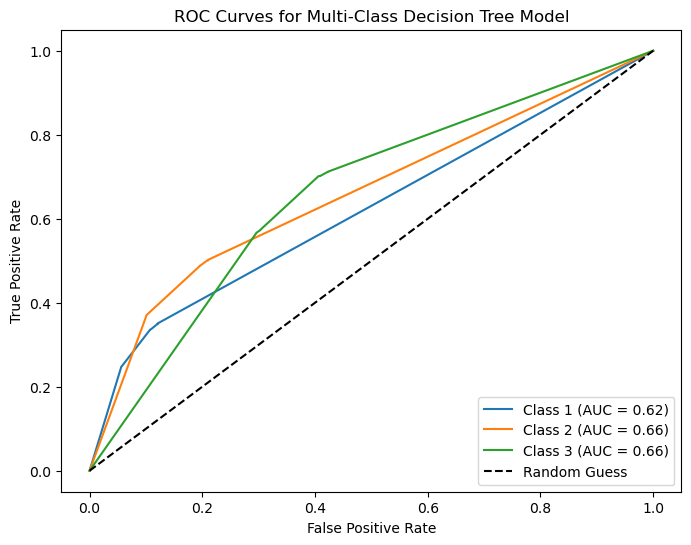

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import numpy as np
import matplotlib.pyplot as plt

# y_test를 이진화 (One-vs-Rest 방식으로 각 클래스별 ROC curve 계산)
y_test_binarized = label_binarize(y_test, classes=np.unique(y_train_balanced))
n_classes = y_test_binarized.shape[1]

# One-vs-Rest 방식으로 다중 클래스 분류 모델 학습
model = OneVsRestClassifier(DecisionTreeClassifier(random_state=0))
model.fit(X_train_balanced, y_train_balanced)
y_score = model.predict_proba(X_test)

# y_score의 NaN 값 확인 및 처리
if np.isnan(y_score).any():
    print("y_score contains NaN values.")
    y_score = np.nan_to_num(y_score)

# 각 클래스에 대해 ROC curve와 AUC 계산
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
    print(f"Class {i+1} AUC: {roc_auc[i]:.2f}")

# ROC curve 그리기
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i+1} (AUC = {roc_auc[i]:0.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class Decision Tree Model')
plt.legend(loc='lower right')
plt.show()


In [ ]:
scores = []

for i in range(10,150,5):
    RF = RandomForestClassifier(n_estimators=i,random_state=0)
    RF.fit(X_train_balanced, y_train_balanced)
           
    att = RF.predict(X_test)
    acc = accuracy_score(y_test, att)
    scores.append(acc)
    
    print('%d, acc: %.3f' % (i,acc))
    


# standare 스케일러 

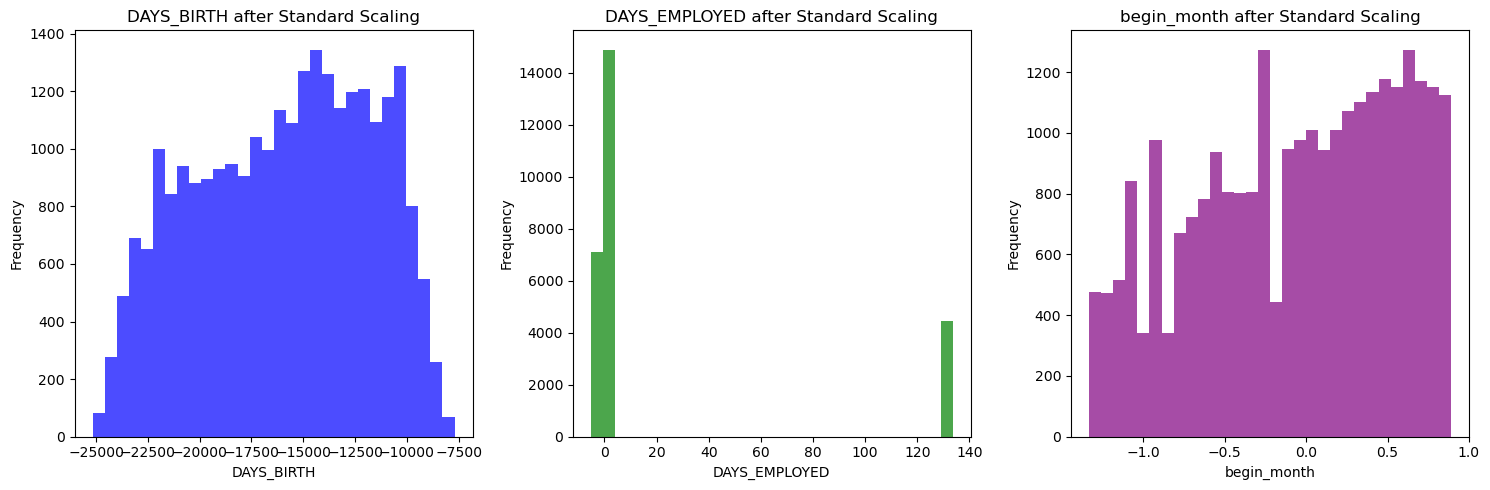

In [25]:
import matplotlib.pyplot as plt

# 스케일링된 각 변수의 분포 히스토그램
plt.figure(figsize=(15, 5))

# DAYS_BIRTH
plt.subplot(1, 3, 1)
plt.hist(df_encoded['DAYS_BIRTH'], bins=30, alpha=0.7, color='blue')
plt.title('DAYS_BIRTH after Standard Scaling')
plt.xlabel('DAYS_BIRTH')
plt.ylabel('Frequency')

# DAYS_EMPLOYED
plt.subplot(1, 3, 2)
plt.hist(df_encoded['DAYS_EMPLOYED'], bins=30, alpha=0.7, color='green')
plt.title('DAYS_EMPLOYED after Standard Scaling')
plt.xlabel('DAYS_EMPLOYED')
plt.ylabel('Frequency')

# begin_month
plt.subplot(1, 3, 3)
plt.hist(df_encoded['begin_month'], bins=30, alpha=0.7, color='purple')
plt.title('begin_month after Standard Scaling')
plt.xlabel('begin_month')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
# standare 스케일러 

In [26]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# DAYS_EMPLOYED에 RobustScaler 적용
robust_scaler = RobustScaler()
df_encoded['DAYS_EMPLOYED'] = robust_scaler.fit_transform(df_encoded[['DAYS_EMPLOYED']])

# begin_month에 MinMaxScaler 적용
minmax_scaler = MinMaxScaler()
df_encoded['begin_month'] = minmax_scaler.fit_transform(df_encoded[['begin_month']])

# 스케일링 후 결과 확인
print(df_encoded[['DAYS_EMPLOYED', 'begin_month']])


print(df_encoded['DAYS_EMPLOYED'].max())


       DAYS_EMPLOYED  begin_month
0          -1.154406     0.900000
1          -0.000364     0.916667
2          -1.054261     0.633333
3          -0.201384     0.383333
4          -0.206118     0.566667
...              ...          ...
26452      -0.162054     0.966667
26453      -0.340859     0.216667
26454      -0.173343     0.583333
26455       0.521486     0.016667
26456       0.191551     0.850000

[26457 rows x 2 columns]
133.56955571740713


# DAY_EMPLOYEE robust / begin_month MinMax

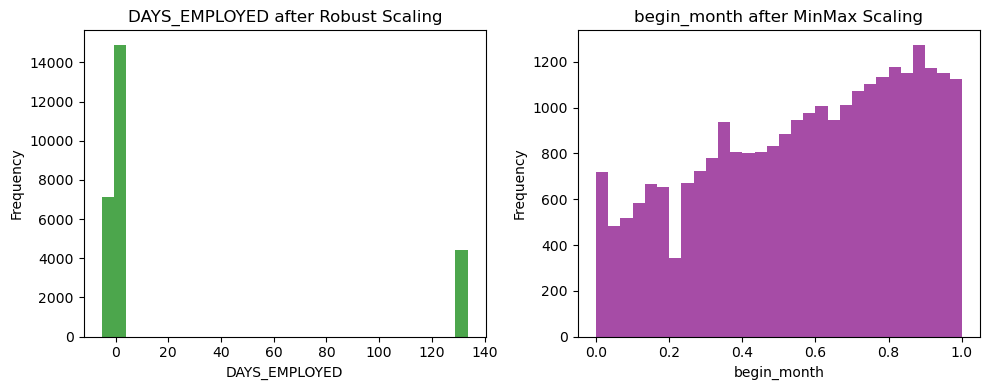

In [27]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# DAYS_EMPLOYED에 RobustScaler 적용
robust_scaler = RobustScaler()
df_encoded['DAYS_EMPLOYED'] = robust_scaler.fit_transform(df_encoded[['DAYS_EMPLOYED']])

# begin_month에 MinMaxScaler 적용
minmax_scaler = MinMaxScaler()
df_encoded['begin_month'] = minmax_scaler.fit_transform(df_encoded[['begin_month']])

# 스케일링 후 분포 시각화
plt.figure(figsize=(10, 4))

# DAYS_EMPLOYED 시각화
plt.subplot(1, 2, 1)
plt.hist(df_encoded['DAYS_EMPLOYED'], bins=30, alpha=0.7, color='green')
plt.title('DAYS_EMPLOYED after Robust Scaling')
plt.xlabel('DAYS_EMPLOYED')
plt.ylabel('Frequency')

# begin_month 시각화
plt.subplot(1, 2, 2)
plt.hist(df_encoded['begin_month'], bins=30, alpha=0.7, color='purple')
plt.title('begin_month after MinMax Scaling')
plt.xlabel('begin_month')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# begin_month robust

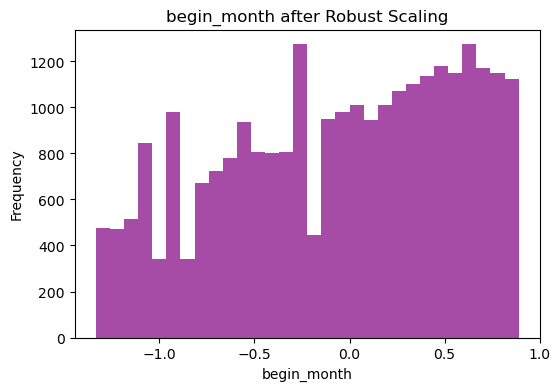

In [28]:
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

# RobustScaler 적용
robust_scaler = RobustScaler()
df_encoded['begin_month'] = robust_scaler.fit_transform(df_encoded[['begin_month']])

# 스케일링 후 분포 시각화
plt.figure(figsize=(6, 4))

# begin_month 시각화
plt.hist(df_encoded['begin_month'], bins=30, alpha=0.7, color='purple')
plt.title('begin_month after Robust Scaling')
plt.xlabel('begin_month')
plt.ylabel('Frequency')

plt.show()


# 스케일링 전 변수분포

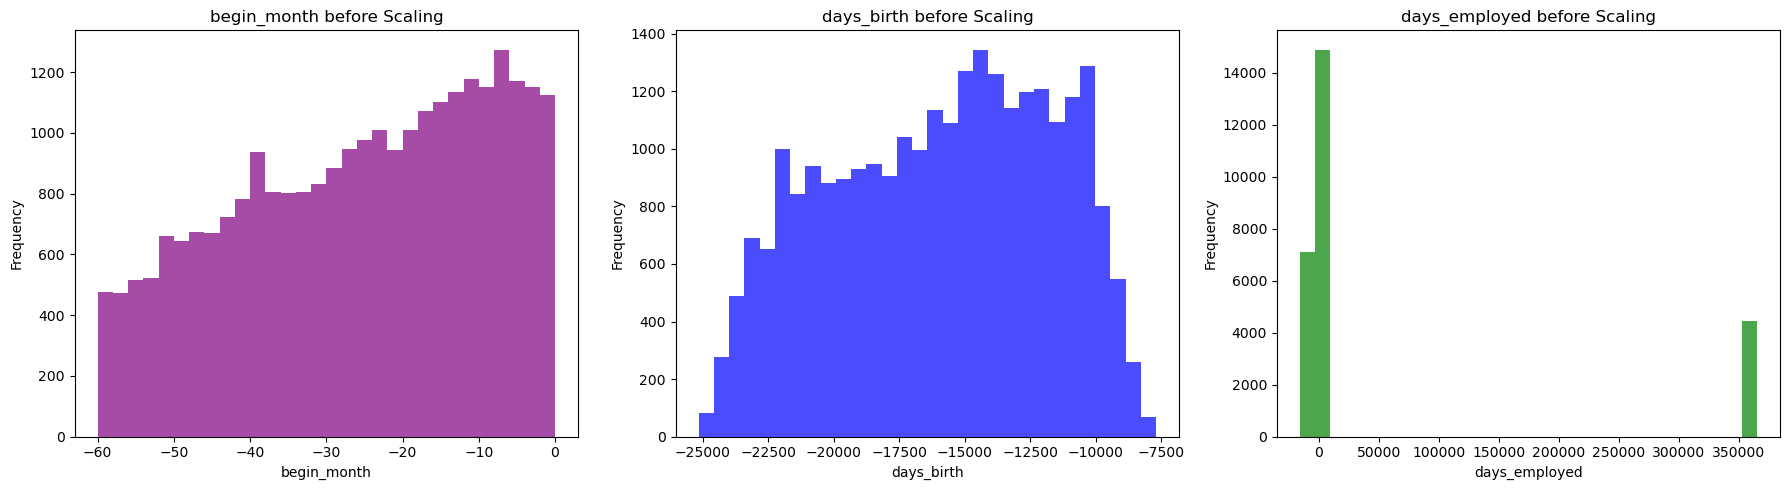

In [29]:
import matplotlib.pyplot as plt

# 스케일링 전 변수 분포 시각화
plt.figure(figsize=(18, 5))

# begin_month 시각화
plt.subplot(1, 3, 1)
plt.hist(df['begin_month'], bins=30, alpha=0.7, color='purple')
plt.title('begin_month before Scaling')
plt.xlabel('begin_month')
plt.ylabel('Frequency')

# days_birth 시각화
plt.subplot(1, 3, 2)
plt.hist(df['DAYS_BIRTH'], bins=30, alpha=0.7, color='blue')
plt.title('days_birth before Scaling')
plt.xlabel('days_birth')
plt.ylabel('Frequency')

# days_employed 시각화
plt.subplot(1, 3, 3)
plt.hist(df['DAYS_EMPLOYED'], bins=30, alpha=0.7, color='green')
plt.title('days_employed before Scaling')
plt.xlabel('days_employed')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
